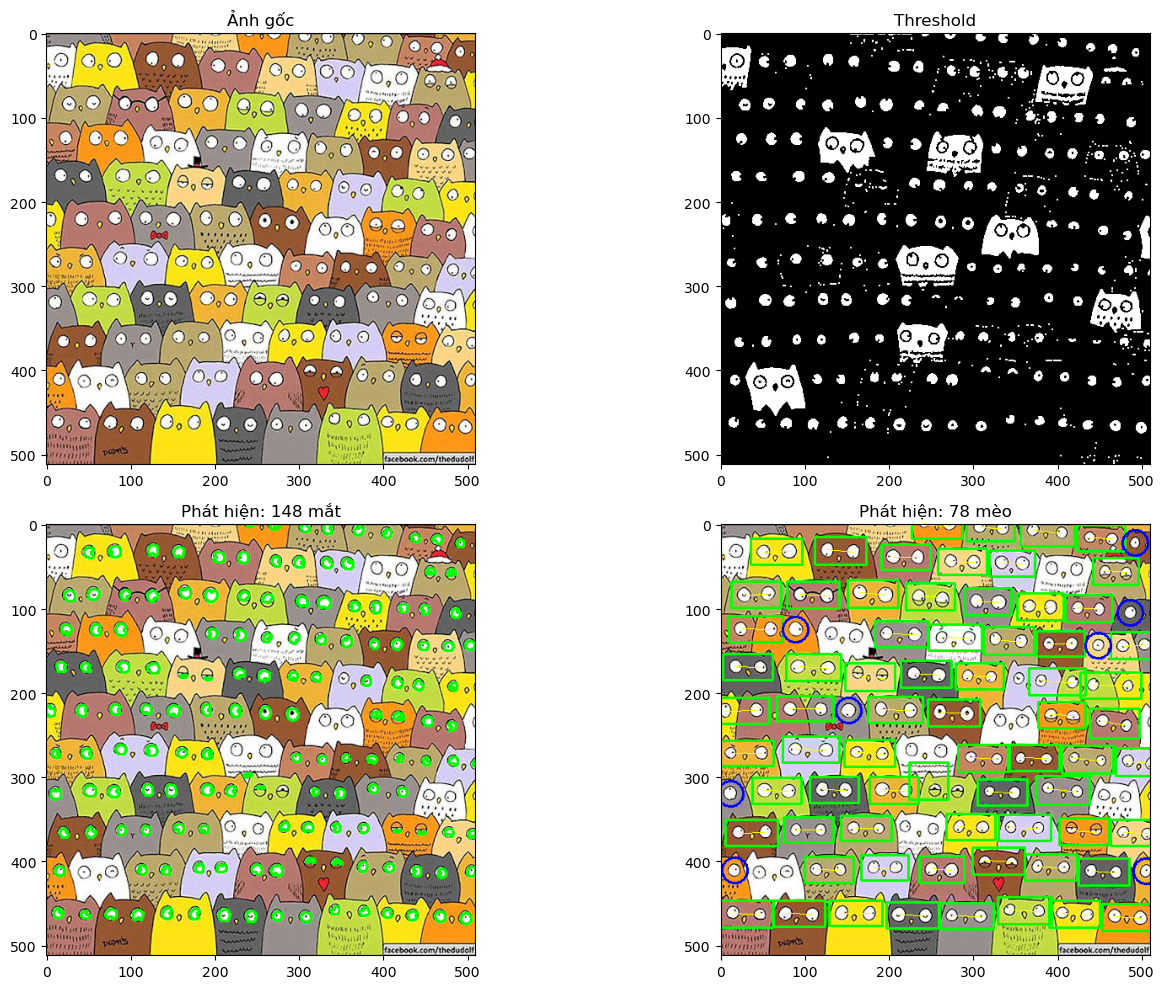

Số lượng mèo phát hiện được: 78


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_cats_eye_detection(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Chuyển sang ảnh xám
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Áp dụng thresholding để tách mắt (màu trắng trên nền tối)
    _, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)
    # _, thresh = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY_INV)
    
    # Lọc nhiễu
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # Tìm contours của mắt
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Lọc contours dựa trên hình dạng (gần tròn) và kích thước
    min_area = 13  # Min
    max_area = 250  # Max
    eye_contours = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            perimeter = cv2.arcLength(cnt, True)
            if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter * perimeter)
                if circularity > 0.35:  # Ngưỡng tròn hạ xuống (1 = hoàn toàn tròn)
                    eye_contours.append(cnt)
    
    # Vẽ contours mắt
    eye_image = image_rgb.copy()
    cv2.drawContours(eye_image, eye_contours, -1, (0, 255, 0), 2)
    
    # Lấy tâm của mỗi mắt
    eye_centers = []
    for cnt in eye_contours:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            eye_centers.append((cx, cy))
    
    # Nhóm các mắt theo cặp dựa trên khoảng cách và vị trí tương đối
    max_dist = 50  # Khoảng cách tối đa giữa hai mắt
    paired_eyes = []
    unpaired_eyes = eye_centers.copy()
    
    # Sắp xếp mắt từ trên xuống dưới, từ trái sang phải
    unpaired_eyes.sort(key=lambda p: (p[1], p[0]))
    
    while len(unpaired_eyes) > 1:
        eye1 = unpaired_eyes[0]
        unpaired_eyes.remove(eye1)
        
        found_pair = False
        best_pair = None
        min_distance = float('inf')
        
        # Tìm mắt thứ 2 gần nhất và phù hợp nhất
        for eye2 in unpaired_eyes:
            dx = abs(eye1[0] - eye2[0])
            dy = abs(eye1[1] - eye2[1])
            
            # Tính khoảng cách Euclidean
            distance = np.sqrt(dx*dx + dy*dy)
            
            # Mắt của một mèo thường:
            # 1. Gần nhau theo khoảng cách tổng thể
            # 2. Nằm gần như cùng một hàng ngang (dy nhỏ)
            if distance < max_dist and dy < max_dist/3:
                # Chọn cặp mắt có khoảng cách gần nhau nhất
                if distance < min_distance:
                    min_distance = distance
                    best_pair = eye2
        
        # Nếu tìm thấy cặp tốt nhất
        if best_pair:
            paired_eyes.append((eye1, best_pair))
            unpaired_eyes.remove(best_pair)
            found_pair = True
        
        # Nếu không tìm thấy cặp, coi đây là mèo có một mắt (hoặc mắt thứ hai không được phát hiện)
        if not found_pair:
            paired_eyes.append((eye1,))
    
    # Thêm mắt lẻ còn lại (nếu có)
    if unpaired_eyes:
        for eye in unpaired_eyes:
            paired_eyes.append((eye,))
    
    # Mỗi cặp mắt tương ứng với một con mèo
    cat_count = len(paired_eyes)
    
    # Vẽ hình chữ nhật quanh mỗi mèo
    cat_image = image_rgb.copy()
    for pair in paired_eyes:
        if len(pair) == 2:
            # Tìm hình chữ nhật bao quanh cặp mắt
            x1, y1 = pair[0]
            x2, y2 = pair[1]
            x = min(x1, x2) - 15
            y = min(y1, y2) - 15
            w = abs(x2 - x1) + 30  # Mở rộng để bao trọn khuôn mặt mèo
            h = abs(y2 - y1) + 30
            
            # Vẽ hình chữ nhật xanh lá cho mèo có 2 mắt
            cv2.rectangle(cat_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Vẽ đường nối 2 mắt
            cv2.line(cat_image, pair[0], pair[1], (255, 255, 0), 1)
        else:
            # Trường hợp chỉ có một mắt - vẽ vòng tròn màu xanh dương
            x, y = pair[0]
            cv2.circle(cat_image, (x, y), 15, (0, 0, 255), 2)
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 10))
    plt.subplot(221), plt.imshow(image_rgb), plt.title('Ảnh gốc')
    plt.subplot(222), plt.imshow(thresh, cmap='gray'), plt.title('Threshold')
    plt.subplot(223), plt.imshow(eye_image), plt.title(f'Phát hiện: {len(eye_contours)} mắt')
    plt.subplot(224), plt.imshow(cat_image), plt.title(f'Phát hiện: {cat_count} mèo')
    plt.tight_layout()
    plt.show()
    
    return cat_count, paired_eyes


count, pairs = count_cats_eye_detection("couting/cat.jpg")
print(f"Số lượng mèo phát hiện được: {count}")

Các diện tích đã phát hiện: [   9    9    9    9   10   12   12   17   22   30   33   38   41   41
   43   44   45   45   47   50   51   51   54   55   56   59   60   63
   64   65   67   69   71   71   73   76   76   77   78   79   79   80
   80   82   83   84   85   86   86   87   89   91   91   92   92   93
   94   94   95   95   96   96   96   96   97   97   97   97   98   99
   99  100  100  100  101  102  102  102  103  103  103  104  104  104
  105  105  106  107  107  108  109  111  111  111  112  112  115  116
  119  119  121  123  123  124  124  124  125  125  126  126  127  128
  129  132  132  134  135  136  136  137  138  140  140  141  141  142
  145  147  147  148  148  149  149  150  151  151  151  152  153  157
  159  159  165  171  176  185  186  195  547 1738 2101 2517 2547 2745
 2792 2971 3080 3644]


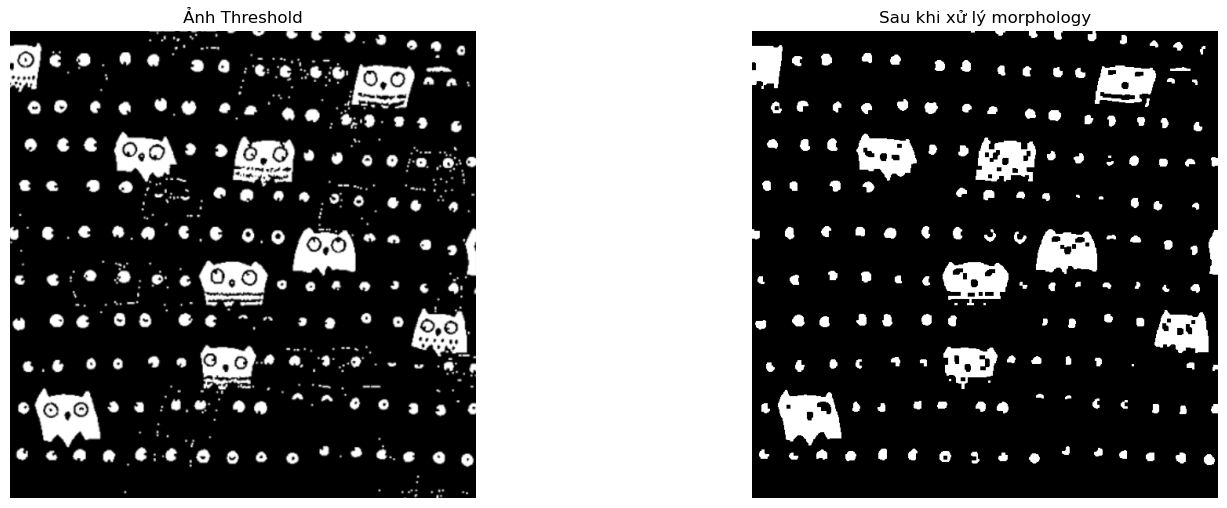

Tổng số connected components: 158
Số lượng mèo trắng: 10


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_white_cats(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(img, 220, 255, cv2.THRESH_BINARY)
    
    # Xóa nhiễu
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Kết nối các thành phần bị gián đoạn bằng phép toán close (dilate rồi erode)
    kernel = np.ones((5, 5), np.uint8)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Tìm các connected components
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(closing, connectivity=8)

    areas = stats[1:, cv2.CC_STAT_AREA]  # Bỏ qua background
    
    # Sắp xếp diện tích để phân tích
    sorted_areas = np.sort(areas)
    print(f"Các diện tích đã phát hiện: {sorted_areas}")
    
    # Đếm số lượng mèo trắng (connected components có diện tích >= area_threshold)
    white_cat_count = np.sum(areas > 500)
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Ảnh Threshold')
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.imshow(closing, cmap='gray')
    plt.title('Sau khi xử lý morphology')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Hiển thị thêm thông tin chi tiết về các connected component
    print(f"Tổng số connected components: {num_labels-1}")
    print(f"Số lượng mèo trắng: {white_cat_count}")
    
    # Trả về số lượng mèo trắng và ảnh kết quả
    return white_cat_count

# Sử dụng hàm
white_cat_count = count_white_cats('couting/threshold.png')

In [43]:
result = white_cat_count + count
result

88

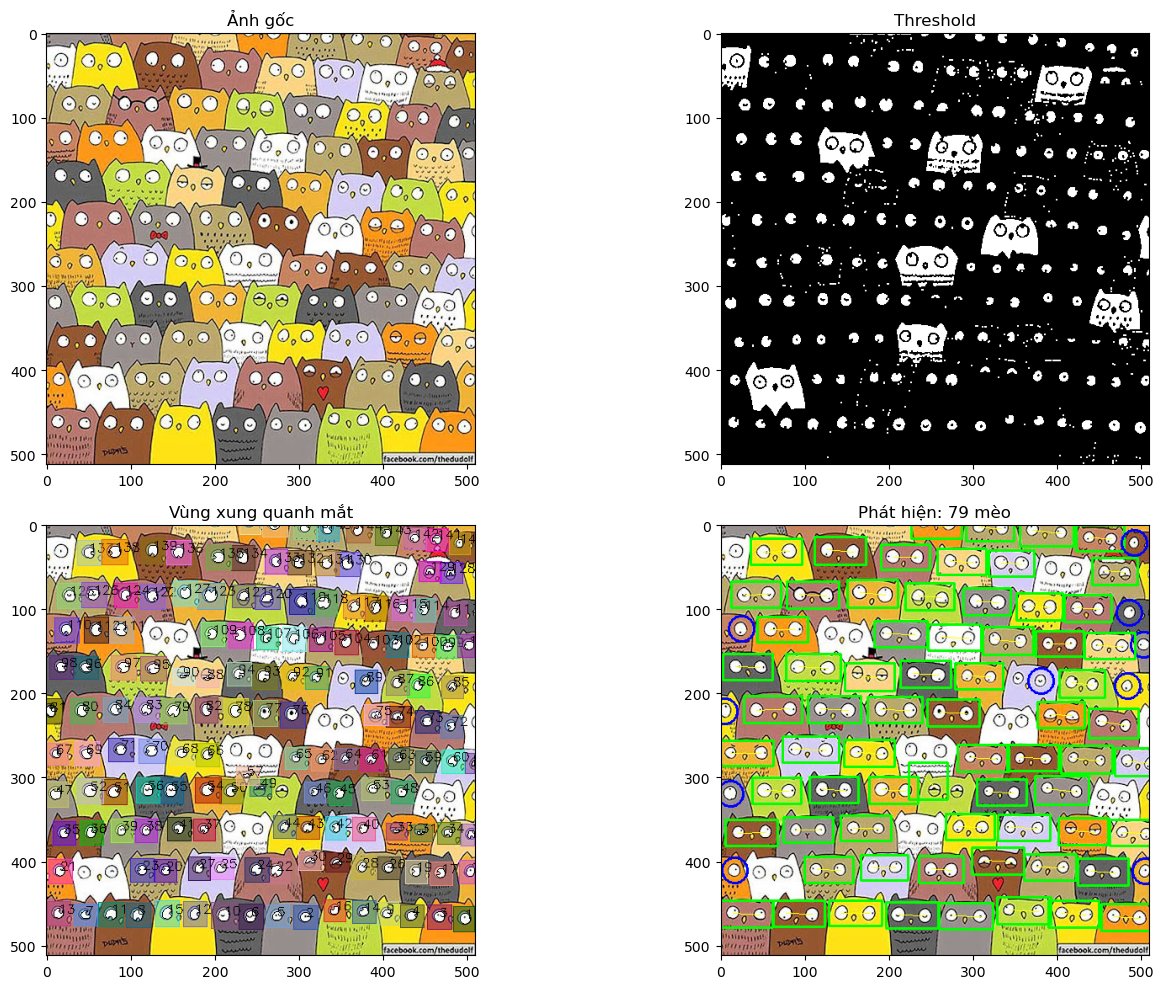

Số lượng mèo phát hiện được: 79


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_cats_eye_detection(image_path):
    # Đọc ảnh màu
    image = cv2.imread(image_path)
    if image is None:
        print(f"Không thể đọc ảnh từ {image_path}")
        return 0, []
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Chuyển sang ảnh xám để phát hiện mắt
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Áp dụng thresholding để tách mắt (màu trắng trên nền tối)
    _, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)
    
    # Lọc nhiễu
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # Tìm contours của mắt
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Lọc contours dựa trên hình dạng (gần tròn) và kích thước
    min_area = 13  # Diện tích tối thiểu của mắt
    max_area = 250  # Diện tích tối đa của mắt
    eye_contours = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            perimeter = cv2.arcLength(cnt, True)
            if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter * perimeter)
                if circularity > 0.35:  # Ngưỡng tròn (1 = hoàn toàn tròn)
                    eye_contours.append(cnt)
    
    # Tạo ảnh để hiển thị vùng xung quanh mắt
    eye_area_image = image_rgb.copy()
    
    # Tìm tâm của mỗi mắt và lấy thông tin màu sắc xung quanh
    eye_centers = []
    eye_colors = []
    eye_surrounding_masks = []  # Lưu các mask vùng xung quanh mắt
    
    for i, cnt in enumerate(eye_contours):
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            
            # Tạo mask cho vùng xung quanh mắt
            mask = np.zeros_like(gray)
            
            # Vẽ vùng lớn hơn contour để lấy màu nền xung quanh mắt
            x, y, w, h = cv2.boundingRect(cnt)
            padding = 8  # Khoảng cách mở rộng
            # Đảm bảo không vượt quá kích thước ảnh
            x_start = max(0, x - padding)
            y_start = max(0, y - padding)
            x_end = min(image_rgb.shape[1], x + w + padding)
            y_end = min(image_rgb.shape[0], y + h + padding)
            
            # Vẽ vùng xung quanh mắt 
            cv2.rectangle(mask, (x_start, y_start), (x_end, y_end), 255, -1)
            
            # Loại bỏ phần mắt (vì chúng ta chỉ muốn màu xung quanh)
            mask_with_hole = mask.copy()
            cv2.drawContours(mask_with_hole, [cnt], 0, 0, -1)
            
            # Lưu mask vùng xung quanh
            eye_surrounding_masks.append(mask_with_hole)
            
            # Vẽ vùng xung quanh mắt trên ảnh (để hiển thị)
            color_mask = np.zeros_like(image_rgb)
            # Màu ngẫu nhiên cho mỗi vùng xung quanh mắt
            random_color = np.random.randint(0, 255, 3).tolist()
            color_mask[mask_with_hole == 255] = random_color
            
            # Áp dụng màu vùng xung quanh lên ảnh với độ trong suốt
            alpha = 0.5  # Độ trong suốt
            eye_area_image[mask_with_hole == 255] = (
                alpha * color_mask[mask_with_hole == 255] + 
                (1 - alpha) * eye_area_image[mask_with_hole == 255]
            ).astype(np.uint8)
            
            # Vẽ đường viền cho vùng xung quanh
            contours_mask, _ = cv2.findContours(mask_with_hole, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(eye_area_image, contours_mask, -1, random_color, 1)
            
            # Lấy màu trung bình của vùng xung quanh mắt
            mean_color = cv2.mean(image_rgb, mask=mask_with_hole)[:3]  # Lấy 3 kênh RGB
            
            # Vẽ mắt với viền
            cv2.drawContours(eye_area_image, [cnt], 0, (0, 0, 0), 1)
            
            # Hiển thị số thứ tự của mắt
            cv2.putText(eye_area_image, f"{i+1}", (cx, cy), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            
            eye_centers.append((cx, cy))
            eye_colors.append(mean_color)
    
    # Vẽ contours mắt trên ảnh khác
    eye_image = image_rgb.copy()
    cv2.drawContours(eye_image, eye_contours, -1, (0, 255, 0), 2)
    
    # Ghép cặp các mắt dựa trên khoảng cách, vị trí tương đối và màu sắc
    max_dist = 70  # Khoảng cách tối đa giữa hai mắt
    color_threshold = 60  # Ngưỡng khác biệt màu sắc
    paired_eyes = []
    
    # Kết hợp tọa độ và màu sắc
    unpaired_eyes = list(zip(eye_centers, eye_colors))
    
    # Sắp xếp mắt từ trên xuống dưới, từ trái sang phải
    unpaired_eyes.sort(key=lambda p: (p[0][1], p[0][0]))
    
    while len(unpaired_eyes) > 1:
        eye1, color1 = unpaired_eyes[0]
        unpaired_eyes.remove((eye1, color1))
        
        found_pair = False
        best_pair = None
        best_color = None
        min_score = float('inf')
        
        # Tìm mắt thứ 2 gần nhất và có màu tương tự
        for eye2, color2 in unpaired_eyes:
            x1, y1 = eye1
            x2, y2 = eye2
            dx = abs(x1 - x2)
            dy = abs(y1 - y2)
            
            # Tính khoảng cách Euclidean
            distance = np.sqrt(dx*dx + dy*dy)
            
            # Tính sự khác biệt màu sắc (Euclidean trong không gian RGB)
            color_diff = np.sqrt(sum((c1-c2)**2 for c1, c2 in zip(color1, color2)))
            
            # Điều kiện ghép cặp: khoảng cách phù hợp, cùng hàng ngang, và màu tương tự
            if (distance < max_dist and dx > dy and dy < max_dist/3 and color_diff < color_threshold):
                # Ưu tiên cặp mắt có khoảng cách gần và màu sắc giống nhau
                # Tạo một điểm số tổng hợp từ khoảng cách và màu
                combined_score = distance * 0.6 + color_diff * 0.4
                
                if combined_score < min_score:
                    min_score = combined_score
                    best_pair = eye2
                    best_color = color2
        
        # Nếu tìm thấy cặp tốt nhất
        if best_pair:
            paired_eyes.append((eye1, best_pair))
            unpaired_eyes.remove((best_pair, best_color))
            found_pair = True
        
        # Nếu không tìm thấy cặp, coi đây là mèo có một mắt
        if not found_pair:
            paired_eyes.append((eye1,))
    
    # Thêm mắt lẻ còn lại (nếu có)
    if unpaired_eyes:
        for eye, _ in unpaired_eyes:
            paired_eyes.append((eye,))
    
    # Mỗi cặp mắt tương ứng với một con mèo
    cat_count = len(paired_eyes)
    
    # Vẽ hình chữ nhật quanh mỗi mèo
    cat_image = image_rgb.copy()
    for pair in paired_eyes:
        if len(pair) == 2:
            # Tìm hình chữ nhật bao quanh cặp mắt
            x1, y1 = pair[0]
            x2, y2 = pair[1]
            x = min(x1, x2) - 15
            y = min(y1, y2) - 15
            w = abs(x2 - x1) + 30  # Mở rộng để bao trọn khuôn mặt mèo
            h = abs(y2 - y1) + 30
            
            # Vẽ hình chữ nhật xanh lá cho mèo có 2 mắt
            cv2.rectangle(cat_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Vẽ đường nối 2 mắt
            cv2.line(cat_image, pair[0], pair[1], (255, 255, 0), 1)
        else:
            # Trường hợp chỉ có một mắt - vẽ vòng tròn màu xanh dương
            x, y = pair[0]
            cv2.circle(cat_image, (x, y), 15, (0, 0, 255), 2)
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 10))
    plt.subplot(221), plt.imshow(image_rgb), plt.title('Ảnh gốc')
    plt.subplot(222), plt.imshow(thresh, cmap='gray'), plt.title('Threshold')
    plt.subplot(223), plt.imshow(eye_area_image), plt.title('Vùng xung quanh mắt')
    plt.subplot(224), plt.imshow(cat_image), plt.title(f'Phát hiện: {cat_count} mèo')
    plt.tight_layout()
    plt.show()
    
    return cat_count, paired_eyes

# Sử dụng hàm
if __name__ == "__main__":
    image_path = "couting/cat.jpg"  # Thay bằng đường dẫn thực tế
    count, pairs = count_cats_eye_detection(image_path)
    print(f"Số lượng mèo phát hiện được: {count}")